# Uber Data Analysis

In [1]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the dataset
df=pd.read_csv('UberDataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


## Data Cleaning

In [3]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [4]:
# dropping unwanted row
df.drop(df.index[1155],inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [5]:
# Replacing wrong data
df['START']=df['START'].str.replace('Kar?chi','Karchi')
df['STOP']=df['STOP'].str.replace('Kar?chi','Karchi')

In [6]:
# Handling Null values in PURPOSE column
df['PURPOSE']=df['PURPOSE'].fillna('Unknown')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1155 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1155 non-null   float64
 6   PURPOSE     1155 non-null   object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [7]:
# Dropping duplicate rows
df.drop_duplicates(inplace=True)

In [8]:
# resetting the index
df.reset_index(inplace=True)
df.drop('index',axis=1,inplace=True)
df.head()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Unknown
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


## Feature Engineering

In [9]:
# changing object datatype to datetime
df['START_DATE']=df['START_DATE'].str.replace('/','-')
df['END_DATE']=df['END_DATE'].str.replace('/','-')
df['START_DATE']=pd.to_datetime(df['START_DATE'])
df['END_DATE']=pd.to_datetime(df['END_DATE'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1154 entries, 0 to 1153
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES       1154 non-null   float64       
 6   PURPOSE     1154 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.2+ KB


In [10]:
# Splitting the START_DATE column to date and time columns
df['DATE']=pd.DatetimeIndex(df['START_DATE']).date
df['TIME']=pd.DatetimeIndex(df['START_DATE']).hour

# converting the time column into four different categories i.e. Morning, Afternoon, Evening, Night
lt=[]
for i in df['TIME']:
  if 0<=i<=10:
    lt.append('Morning')
  elif 11<=i<=15:
    lt.append('Afternoon')
  elif 16<=i<=19:
    lt.append('Evening')
  elif 20<=i<=24:
    lt.append('Night')

df['DAY-NIGHT']=lt
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon
...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karchi,Karchi,0.7,Meeting,2016-12-31,1,Morning
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karchi,Unknown Location,3.9,Temporary Site,2016-12-31,13,Afternoon
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,Afternoon
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,Night


In [11]:
# creating month column
df['MONTH']=[i.month for i in df['START_DATE']]
df['MONTH']=df['MONTH'].map({1:'JAN',2:'FEB',3:'MAR',4:'APR',5:'MAY',6:'JUN',7:'JUL',8:'AUG',9:'SEP',10:'OCT',11:'NOV',12:'DEC'})
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,JAN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,Morning,JAN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night,JAN
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,JAN
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,JAN
...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karchi,Karchi,0.7,Meeting,2016-12-31,1,Morning,DEC
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karchi,Unknown Location,3.9,Temporary Site,2016-12-31,13,Afternoon,DEC
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,Afternoon,DEC
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,Night,DEC


In [12]:
# creating day column
df['DAY']=df['START_DATE'].dt.weekday
df['DAY']=df['DAY'].map({0:'MON',1:'TUE',2:'WED',3:'THU',4:'FRI',5:'SAT',6:'SUN'})
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT,MONTH,DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,JAN,FRI
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,Morning,JAN,SAT
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night,JAN,SAT
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,JAN,TUE
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,JAN,WED
...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karchi,Karchi,0.7,Meeting,2016-12-31,1,Morning,DEC,SAT
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karchi,Unknown Location,3.9,Temporary Site,2016-12-31,13,Afternoon,DEC,SAT
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,Afternoon,DEC,SAT
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,Night,DEC,SAT


##EDA

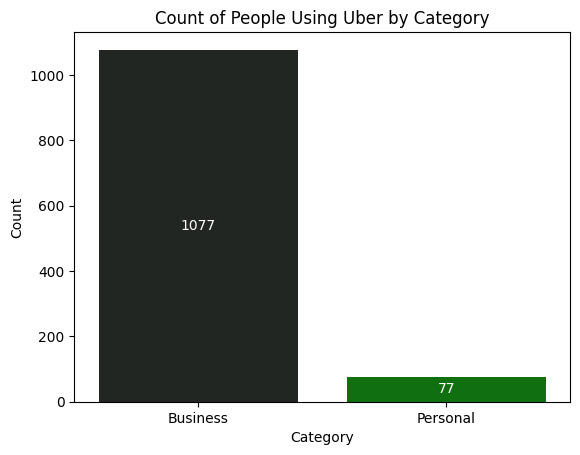

In [17]:
# Count of people using Uber for different purposes
a=sns.countplot(x='CATEGORY',data=df,hue='CATEGORY',palette='dark:Green')
def data_label(a):
  for i in a.containers:
    a.bar_label(i,label_type='center',color='white')
data_label(a)
plt.title("Count of People Using Uber by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

Most of the customers prefer uber for Business purpose

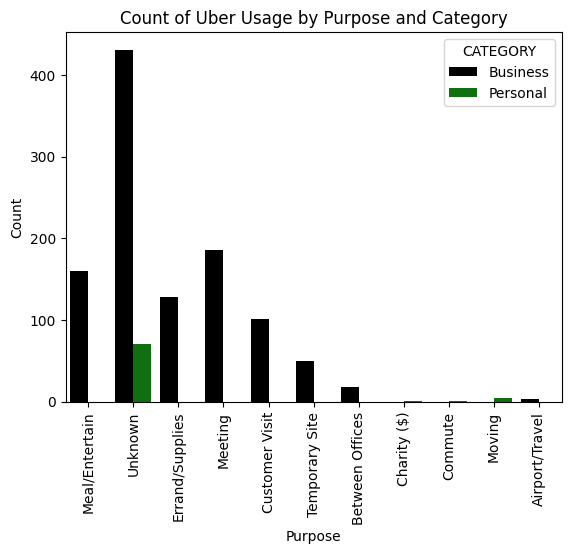

In [18]:
# Count of Uber Usage by Purpose and Category
uber_palette = sns.color_palette(["black","green"])
a=sns.countplot(x='PURPOSE',data=df,hue='CATEGORY',palette=uber_palette)
plt.xticks(rotation=90)
plt.title("Count of Uber Usage by Purpose and Category")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.show()

The majority of Uber rides are taken for Business meetings

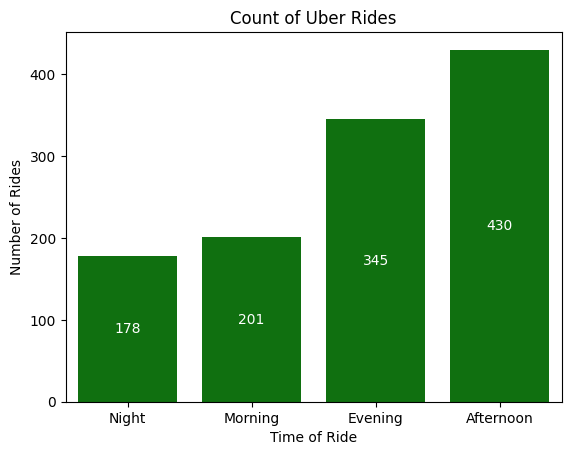

In [22]:
# Count of Uber Rides
a=sns.countplot(x='DAY-NIGHT',data=df,color='Green')
data_label(a)
plt.title("Count of Uber Rides")
plt.xlabel("Time of Ride")
plt.ylabel("Number of Rides")
plt.show()

Most of the uber rides happen in the afternoon

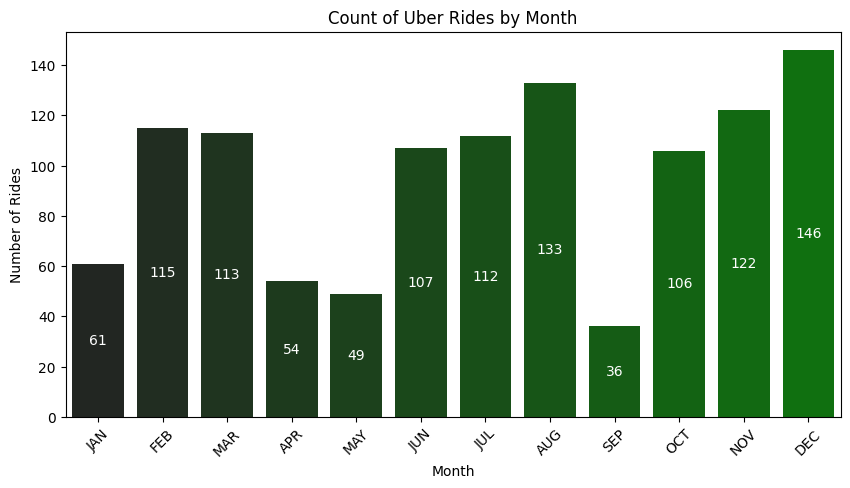

In [23]:
# Count of Uber Rides by Month
plt.figure(figsize=(10,5))
a=sns.countplot(x='MONTH',data=df,hue='MONTH',palette='dark:green')
data_label(a)
plt.title("Count of Uber Rides by Month")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()

Peak uber usage happens in the months of december, august and november

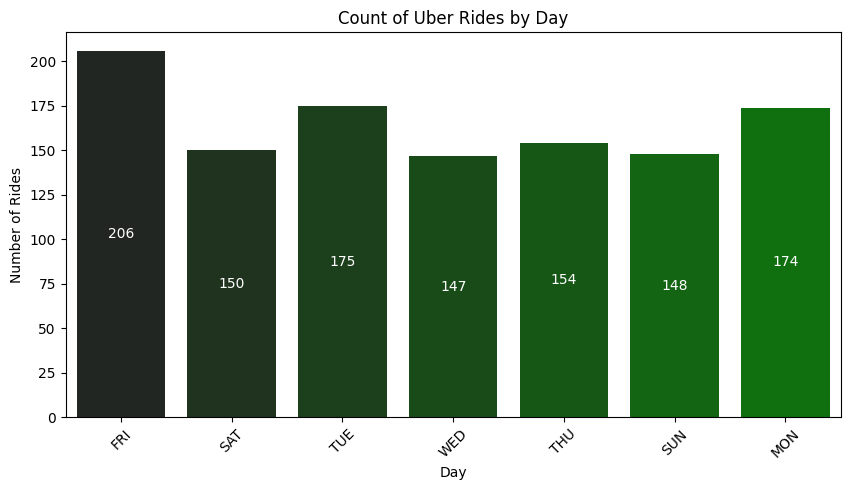

In [25]:
# Count of Uber Rides by Day
plt.figure(figsize=(10,5))
a=sns.countplot(x='DAY',data=df,hue='DAY',palette='dark:green')
data_label(a)
plt.title("Count of Uber Rides by Day")
plt.xlabel("Day")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()

Peak uber usage happens on friday

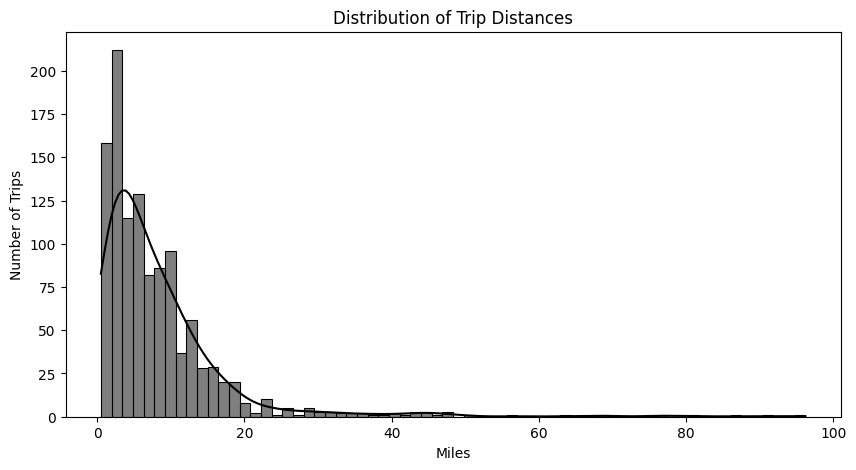

In [26]:
# Distribution of Trip Distances
plt.figure(figsize=(10,5))
sns.histplot(x='MILES',data=df[df['MILES']<100],kde=True,color='black')
plt.title("Distribution of Trip Distances")
plt.xlabel("Miles")
plt.ylabel("Number of Trips")
plt.show()

Most of the Uber trips are short between 10 to 15 miles

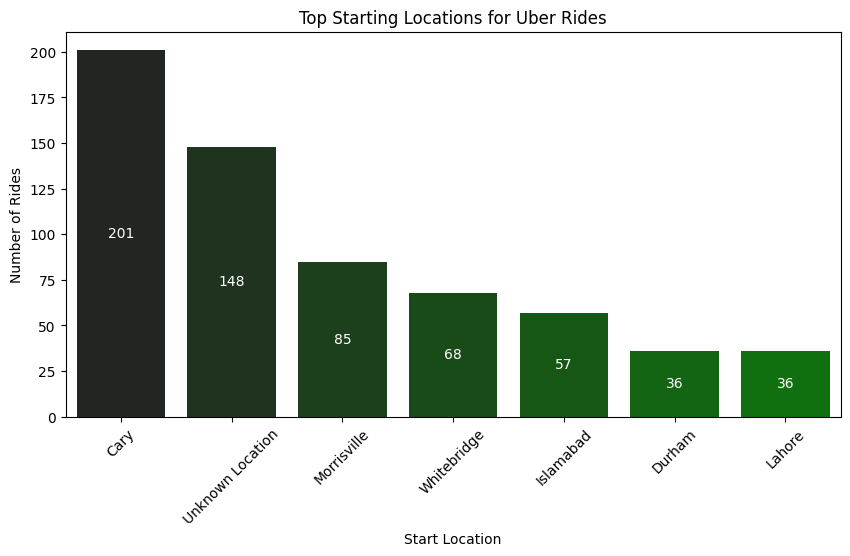

In [27]:
# Top Starting Locations for Uber Rides
df1=pd.DataFrame(df['START'].value_counts())
plt.figure(figsize=(10,5))
a=sns.barplot(x='START',y='count',data=df1[df1['count']>30],hue='START',palette='dark:green')
data_label(a)
plt.title("Top Starting Locations for Uber Rides")
plt.xlabel("Start Location")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()

The most frequent starting point for Uber rides is cary

## Recommendations:
1. As most rides are for business meetings, Uber can offer business travel packages.
2. With peak demand in the afternoon, Uber should ensure more driver availability during these hours to reduce waiting time.
3. High bookings are in August, November, and December so Uber should prepare driver incentives for these months.
4. As Cary is the most frequent starting location, Uber can prioritize  more driver allocation in that location.